# Mooooodellllll

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
import holidays
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


import pickle
from pathlib import Path
import re
import shutil

import shap

# Linear
from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)

# Tree / Ensemble
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from datetime import datetime

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

model_dir = Path("saved_models")
if model_dir.exists():
    shutil.rmtree(model_dir)
model_dir.mkdir()

shap_dir = Path("shap_outputs")
if shap_dir.exists():
    shutil.rmtree(shap_dir)
shap_dir.mkdir()

C:\Users\kvillaera\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def read_sheets(filename):
    """Read the input data"""
    sheets = pd.read_excel(filename, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
    return df.shape, df

df_time_shape, df_time = read_sheets("time_card_daily_latest.xlsx")
print(f"Time shape: {df_time_shape}")

Time shape: (131036, 16)


In [5]:
df_new_shape, df_new = read_sheets("time_card_daily_0707.xlsx")
print(f"New shape: {df_new_shape}")

New shape: (6526, 16)


In [6]:
before_append = df_time.shape[0]
df_time = pd.concat([df_time, df_new], ignore_index=True)
after_append = df_time.shape[0]

df_time = df_time.drop_duplicates(keep='first')
after_dedup = df_time.shape[0]

new_rows_added = after_append - after_dedup
print(f"New rows added: {new_rows_added}")

New rows added: 4143


## ABT Build

In [7]:
df_time["Date"] = pd.to_datetime(df_time["Date"])
task_types = ["INC", "CHG", "SCT"]

df_time["is_sick_or_holiday"] = df_time["Category"].isin(["Sick/Holiday"]).astype(int)

df_time = df_time[
    df_time["Task"].str.startswith(tuple(task_types), na=False)
    | df_time["Category"].isin(["Sick/Holiday"])
]

## Feature Engineering - Demand 

* Note that the ABT will be different depending on the model. This notebook only contains the DEMAND models.

In [8]:
abt = df_time.drop(
    ["Task", "Category", "User ID", "Rate type",
     "Additional comments", "Grade", "Business Services",
     "Short description", "Company", "Business service", "Project ID", "User"], axis=1)
abt.head(3)

,Date,Technology,Time worked,Specialisation,is_sick_or_holiday
0,2024-05-01,Dynamics 365 FO,1.0,NaN,0
3,2024-05-01,Dynamics 365 FO,0.5,NaN,0
4,2024-05-01,Dynamics 365 FO,1.0,NaN,0


In [9]:
TECH_MAP = {
    "Dynamics 365 FO": "F&O",
    "Dynamics 365 FSCM": "F&O",
    "Dynamics 365 CE": "CE",
    "Dynamics 365 BC": "BC",
    "Dynamics NAV": "BC",
    "Microsoft Azure": "Azure Integ",
    "Microsoft Cloud Data Warehouse": "Inf Mgmt",
    "Microsoft Cloud Support Infrastructure": "Inf Mgmt",
    "Power Platform": "Power Platform",
}

abt["tech_group"] = abt["Technology"].map(TECH_MAP)

In [10]:
abt["tech_group"].value_counts()

tech_group
F&O               34700
CE                16602
BC                 3122
Inf Mgmt           2274
Azure Integ        2268
Power Platform      907
Name: count, dtype: int64

In [11]:
abt.drop(["Technology", "Specialisation"], axis=1, inplace=True)

In [12]:
def one_hot_encode(df, columns, drop_first=False, dummy_na=False, dtype="int"):
    df_encoded = pd.get_dummies(
        df,
        columns=columns,
        drop_first=drop_first,
        dummy_na=dummy_na
    )
    dummy_cols = [col for col in df_encoded.columns 
                  if any(col.startswith(f"{c}_") for c in columns)]
    
    df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(dtype)

    return df_encoded

abt_encoded = abt.copy()
abt_encoded["Date"] = pd.to_datetime(abt_encoded["Date"])
abt_encoded = abt_encoded.sort_values(by="Date", ascending=True)
abt_encoded.head(3)

,Date,Time worked,is_sick_or_holiday,tech_group
0,2024-05-01,1.0,0,F&O
40,2024-05-01,4.0,0,CE
43,2024-05-01,8.0,1,NaN


In [13]:
abt_encoded["tech_group"] = (
    abt_encoded["tech_group"]
    .fillna(abt_encoded["tech_group"].mode().iloc[0])
)

In [14]:
abt_encoded["week"] = abt_encoded["Date"].dt.to_period("W-SUN").dt.start_time

In [15]:
global_end = abt_encoded["week"].max()
global_start = abt_encoded["week"].min()

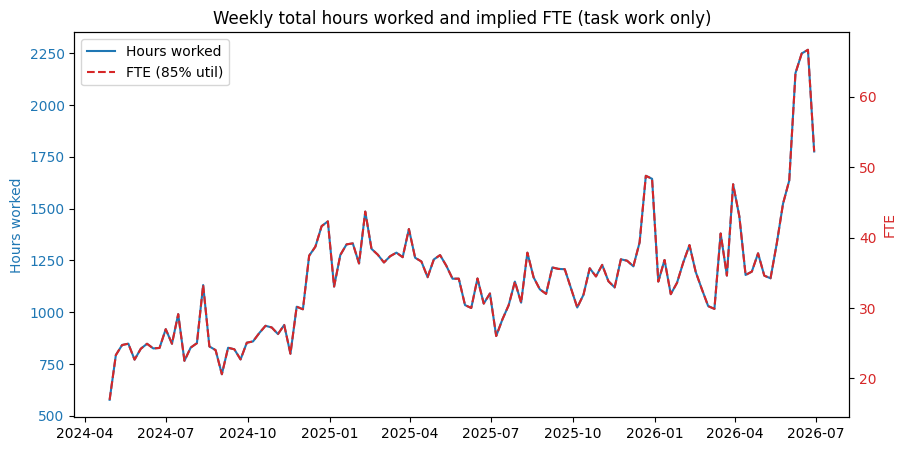

In [16]:
weekly_sum = abt_encoded.groupby("week")["Time worked"].sum()

# Compute FTE per week at 85% utilization (40h full-time)
hours_per_fte_per_week = 40 * 0.85
weekly_fte = weekly_sum / hours_per_fte_per_week

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot hours on left axis
ax1.plot(weekly_sum.index, weekly_sum.values, label="Hours worked", color="tab:blue")
ax1.set_title("Weekly total hours worked and implied FTE (task work only)")
ax1.set_ylabel("Hours worked", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Plot FTE on right axis
ax2 = ax1.twinx()
ax2.plot(weekly_fte.index, weekly_fte.values, label="FTE (85% util)", color="tab:red", linestyle="--")
ax2.set_ylabel("FTE", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()

In [17]:
def aggregate_df(
    df,
    spike_dates=None,
    dip_dates=None,
    holiday_dates=None
):

    df = df.copy()

    df["Date"] = pd.to_datetime(df["Date"])

    df["week"] = df["Date"].dt.to_period("W-SUN").dt.start_time

    df["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)
    df["month"] = df["week"].dt.month
    df["is_month_end"] = df["week"].dt.is_month_end.astype(int)
    df["is_quarter_end"] = df["week"].dt.is_quarter_end.astype(int)

    # Spike flag
    if spike_dates is not None:
        spike_dates = pd.to_datetime(spike_dates)
        df["is_spike"] = (
            df["Date"].dt.normalize().isin(spike_dates)
        ).astype(int)
    else:
        df["is_spike"] = 0

    # Dip flag
    if dip_dates is not None:
        dip_dates = pd.to_datetime(dip_dates)
        df["is_dip"] = (
            df["Date"].dt.normalize().isin(dip_dates)
        ).astype(int)
    else:
        df["is_dip"] = 0

    # Holiday flag
    if holiday_dates is not None:
        holiday_dates = pd.to_datetime(holiday_dates)
        df["is_holiday"] = (
            df["Date"].dt.normalize().isin(holiday_dates)
        ).astype(int)
    else:
        df["is_holiday"] = 0

    # Numeric columns containing underscores
    underscore_cols = [
        col
        for col in df.columns
        if "_" in col and pd.api.types.is_numeric_dtype(df[col])
    ]

    # Avoid duplicates
    underscore_cols = [
        c for c in underscore_cols
        if c not in ["is_spike", "is_dip", "is_holiday"]
    ]

    agg_cols = [
        "Time worked",
        "is_spike",
        "is_dip",
        "is_holiday",
        *underscore_cols,
    ]

    weekly_df = (
        df.groupby("week")[agg_cols]
        .sum()
        .reset_index()
        .sort_values("week")
    )

    weekly_df["week_of_year"] = (
        weekly_df["week"].dt.isocalendar().week.astype(int)
    )
    weekly_df["month"] = weekly_df["week"].dt.month
    weekly_df["is_month_end"] = weekly_df["week"].dt.is_month_end.astype(int)
    weekly_df["is_quarter_end"] = weekly_df["week"].dt.is_quarter_end.astype(int)

    weekly_df["is_holiday"] = (
        weekly_df["is_holiday"] > 0
    ).astype(int)

    return weekly_df

In [18]:
grouped_dfs = {
    tech: df
    for tech, df in abt.groupby("tech_group")
}

In [19]:
mt_holidays = holidays.MT(years=[2024, 2025, 2026])
uk_holidays = holidays.UK(years=[2024, 2025, 2026])

holiday_dates = list(
    set(mt_holidays.keys()) | set(uk_holidays.keys())
)

for i in grouped_dfs:
    grouped_dfs[i] = aggregate_df(grouped_dfs[i], spike_dates=None, holiday_dates=holiday_dates)

In [20]:
def fill_missing_weeks(
    weekly_df: pd.DataFrame,
    global_start: pd.Timestamp,
    global_end: pd.Timestamp,
    time_col: str = "Time worked",
    freq: str = "W-MON",
) -> pd.DataFrame:
    """
    weekly_df: output from aggregate_df, with a 'week' column (datetime at week start)
    time_col: column to fill with 0 for missing weeks
    freq: week frequency, e.g. 'W-MON' or 'W-SUN'
    global_start: global start date (e.g. '2024-01-01' or pd.Timestamp('2024-01-01'))
    global_end: global end date (e.g. '2026-12-31' or pd.Timestamp('2026-12-31'))
    """
    weekly_df = weekly_df.copy()

    # Ensure week is datetime and sorted
    weekly_df["week"] = pd.to_datetime(weekly_df["week"])
    weekly_df = weekly_df.sort_values("week").reset_index(drop=True)

    # Use global range if provided, otherwise use dataframe range
    start = pd.to_datetime(global_start) if global_start is not None else weekly_df["week"].min()
    end = pd.to_datetime(global_end) if global_end is not None else weekly_df["week"].max()

    full_range = pd.date_range(start=start, end=end, freq=freq)

    # Set week as index, reindex to full range, fill missing with 0 for time_col
    weekly_df_idx = weekly_df.set_index("week")
    weekly_df_complete = weekly_df_idx.reindex(full_range, fill_value=0)

    weekly_df_complete = weekly_df_complete.reset_index()
    weekly_df_complete = weekly_df_complete.rename(columns={"index": "week"})

    return weekly_df_complete

In [21]:
def flag_weekly_spikes_dips_rolling_preceding(
    weekly_df: pd.DataFrame,
    time_col: str = "Time worked",
    threshold_pct: float = 0.40,
    window: int = 2,
    baseline: str = "median",
    min_periods: int = 2  # require at least 2 preceding weeks
) -> pd.DataFrame:
    weekly_df = weekly_df.copy()
    weekly_df = weekly_df.sort_values("week").reset_index(drop=True)

    if baseline == "median":
        rolling_base = weekly_df[time_col].rolling(window=window, min_periods=min_periods).median()
    elif baseline == "mean":
        rolling_base = weekly_df[time_col].rolling(window=window, min_periods=min_periods).mean()
    else:
        raise ValueError("baseline must be 'median' or 'mean'")

    # Shift: baseline uses only preceding weeks
    rolling_base = rolling_base.shift(1)

    lower = rolling_base * (1 - threshold_pct)
    upper = rolling_base * (1 + threshold_pct)

    # Only flag when baseline exists (i.e., there are enough preceding weeks)
    weekly_df["is_dip"] = (
        (lower.notna()) & (weekly_df[time_col] < lower)
    ).astype(int)

    weekly_df["is_spike"] = (
        (upper.notna()) & (weekly_df[time_col] > upper)
    ).astype(int)

    return weekly_df

### Manually identify weeks with spikes and dips in the ABT

In [22]:
for i in grouped_dfs:
    temp = grouped_dfs[i]
    if len(temp) > 3:
        temp = fill_missing_weeks(temp, global_start, global_end)
        temp = flag_weekly_spikes_dips_rolling_preceding(temp)
        grouped_dfs[i] = temp

## Model Selection

In [23]:
def get_models():

    return {

        "Ridge": (
            Ridge(),
            {"alpha": [0.01, 0.1, 1, 10]}
        ),

        "Lasso": (
            Lasso(),
            {"alpha": [0.01, 0.1, 1]}
        ),

        "ElasticNet": (
            ElasticNet(),
            {"alpha": [0.01, 0.1, 1]}
        ),

        "BayesianRidge": (
            BayesianRidge(),
            {
                "alpha_1": [1e-6, 1e-5],
                "lambda_1": [1e-6, 1e-5]
            }
        ),

        "Huber": (
            HuberRegressor(),
            {
                "epsilon": [1.1, 1.35, 1.5]
            }
        ),

        "DecisionTree": (
            DecisionTreeRegressor(),
            {
                "max_depth": [3, 5, 10]
            }
        ),

        "RandomForest": (
            RandomForestRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500],
                "max_depth": [3, 5, 10]
            }
        ),

        "ExtraTrees": (
            ExtraTreesRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500]
            }
        ),

        "GradientBoosting": (
            GradientBoostingRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.05, 0.1]
            }
        ),

        "AdaBoost": (
            AdaBoostRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500]
            }
        ),

        "XGBoost": (
            XGBRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500],
                "max_depth": [3, 5],
                "learning_rate": [0.05, 0.1]
            }
        ),

        "LightGBM": (
            LGBMRegressor(
                verbosity=-1,
                random_state=42
            ),
            {
                "n_estimators": [100, 200, 500],
                "num_leaves": [15, 31],
                "learning_rate": [0.05, 0.1]
            }
        ),

        "SVR": (
            SVR(),
            {
                "C": [0.1, 1, 10]
            }
        ),

        "KNN": (
            KNeighborsRegressor(),
            {
                "n_neighbors": [3, 5, 7]
            }
        )
    }

In [24]:
def build_features(df_group):

    df_group = df_group.copy()

    if "week" in df_group.columns:
        df_group = df_group.sort_values("week")

    df_group["lag_1"] = df_group["Time worked"].shift(1)
    df_group["lag_2"] = df_group["Time worked"].shift(2)
    df_group["rolling_4"] = (
        df_group["Time worked"]
        .rolling(4)
        .mean()
    )

    df_group = df_group.dropna()

    y = df_group["Time worked"]

    X = df_group.drop(
        columns=["Time worked", "week"],
        errors="ignore"
    )

    X = X.loc[:, X.nunique() > 1]

    return df_group, X, y

In [25]:
def find_best_model(
    group_name,
    X_train,
    X_test,
    y_train,
    y_test,
    n_obs
):

    results = []

    best_model = None
    best_preds = None
    best_mae = float("inf")
    best_mape = float("inf")
    best_name = None

    tscv = TimeSeriesSplit(n_splits=5)

    for name, (model, params) in get_models().items():

        try:

            search = RandomizedSearchCV(
                estimator=model,
                param_distributions=params,
                n_iter=20,
                cv=tscv,
                scoring="neg_mean_absolute_error",
                random_state=42,
                n_jobs=-1
            )

            search.fit(
                X_train,
                y_train
            )

            estimator = search.best_estimator_

            preds = estimator.predict(X_test)

            mae = mean_absolute_error(
                y_test,
                preds
            )

            mape = mean_absolute_percentage_error(
                y_test,
                preds
            )

            results.append({
                "group": group_name,
                "model": name,
                "MAE": mae,
                "MAPE": mape,
                "n_obs": n_obs,
                "best_params": search.best_params_
            })

            if mae < best_mae:

                best_model = estimator
                best_preds = preds
                best_mae = mae
                best_mape = mape
                best_name = name

        except Exception as e:

            print(
                f"{group_name} | {name} failed: {e}"
            )

    return (
        results,
        best_model,
        best_preds,
        best_name,
        best_mae,
        best_mape
    )

In [26]:
def plot_predictions(
    group_name,
    df_group,
    y,
    y_train,
    y_test,
    best_preds,
    best_name,
    best_mae,
    split_idx
):

    plt.figure(figsize=(12, 5))

    weeks = df_group["week"]

    plt.plot(
        weeks,
        y,
        label="Historical",
        alpha=0.4
    )

    plt.plot(
        weeks[:split_idx],
        y_train,
        label="Train"
    )

    plt.plot(
        weeks[split_idx:],
        y_test,
        label="Actual"
    )

    plt.plot(
        weeks[split_idx:],
        best_preds,
        linestyle="--",
        label=f"{best_name} Predicted"
    )

    plt.axvline(
        weeks.iloc[split_idx],
        color="black",
        linestyle=":"
    )

    plt.xticks(rotation=45)

    plt.title(
        f"{group_name} | {best_name} | MAE={best_mae:.2f}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

In [27]:
def generate_xgb_explainability(
    group_name,
    X_train,
    y_train,
    shap_dir
):

    explain_model = XGBRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1
    )

    explain_model.fit(
        X_train,
        y_train
    )

    importance_df = pd.DataFrame({
        "group": group_name,
        "feature": X_train.columns,
        "importance": explain_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )

    sample_size = min(
        1000,
        len(X_train)
    )

    shap_sample = X_train.sample(
        sample_size,
        random_state=42
    )

    explainer = shap.TreeExplainer(
        explain_model
    )

    shap_values = explainer.shap_values(
        shap_sample
    )

    safe_name = re.sub(
        r"[^A-Za-z0-9_-]",
        "_",
        str(group_name)
    )

    shap.summary_plot(
        shap_values,
        shap_sample,
        show=False
    )

    plt.savefig(
        shap_dir /
        f"{safe_name}_shap_summary.png",
        bbox_inches="tight"
    )

    plt.close()

    shap.summary_plot(
        shap_values,
        shap_sample,
        plot_type="bar",
        show=False
    )

    plt.savefig(
        shap_dir /
        f"{safe_name}_shap_bar.png",
        bbox_inches="tight"
    )

    plt.close()

    return importance_df

In [28]:
def save_model(
    group_name,
    best_model,
    X,
    y,
    df_group,
    best_name,
    best_mae,
    best_mape,
    model_dir
):

    best_model.fit(X, y)

    filename = (
        model_dir /
        f"{group_name}__{best_name}.pkl"
    )

    package = {
        "model": best_model,
        "features": list(X.columns),
        "history": (
            df_group["Time worked"]
            .tail(20)
            .tolist()
        ),
        "last_week": (
            df_group["week"]
            .max()
        ),
        "tech_group": group_name,
        "best_model_name": best_name,
        "mae": best_mae,
        "mape": best_mape
    }

    with open(filename, "wb") as f:
        pickle.dump(package, f)

    print(f"Saved: {filename}")

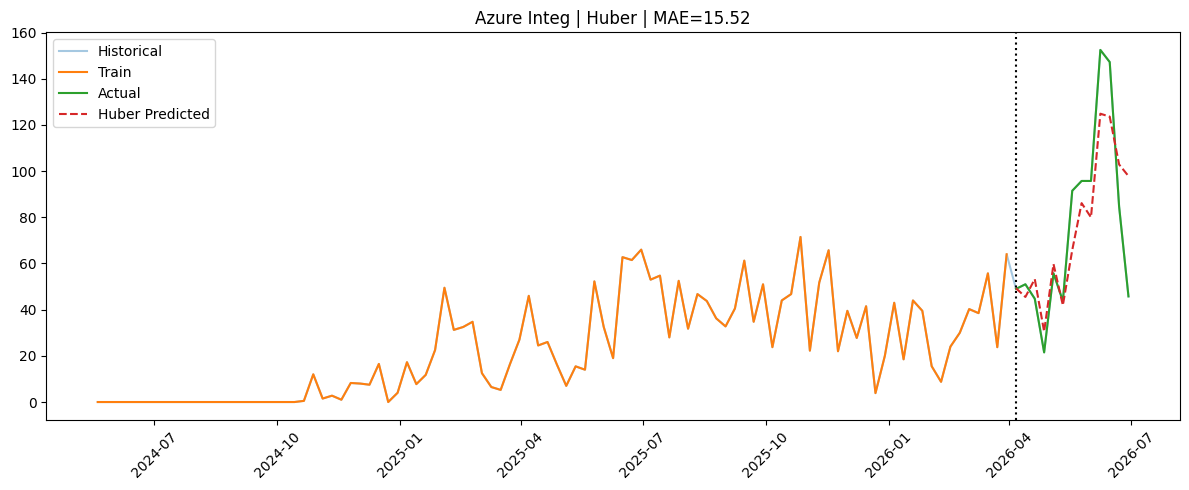

Saved: saved_models\Azure Integ__Huber.pkl


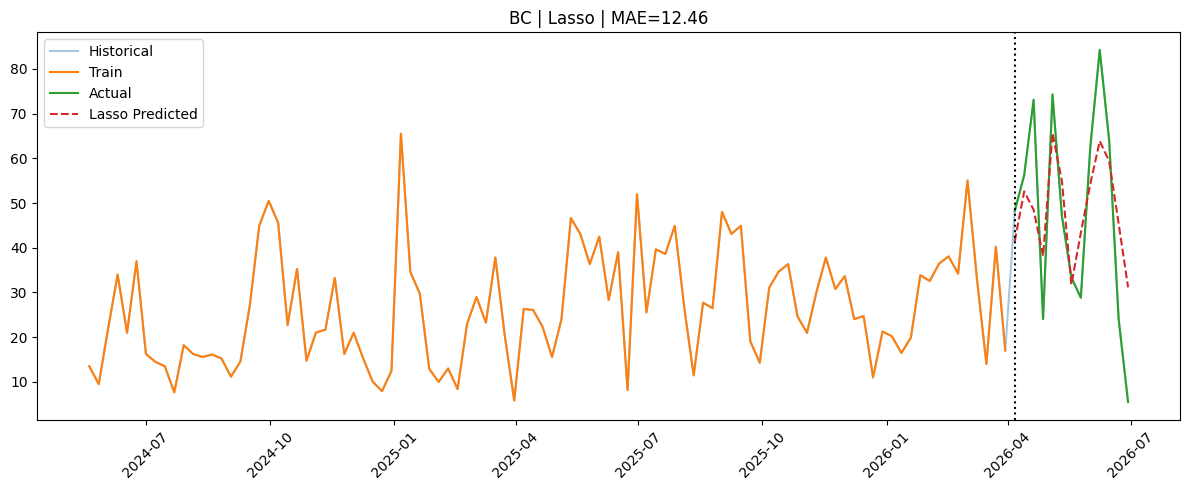

Saved: saved_models\BC__Lasso.pkl


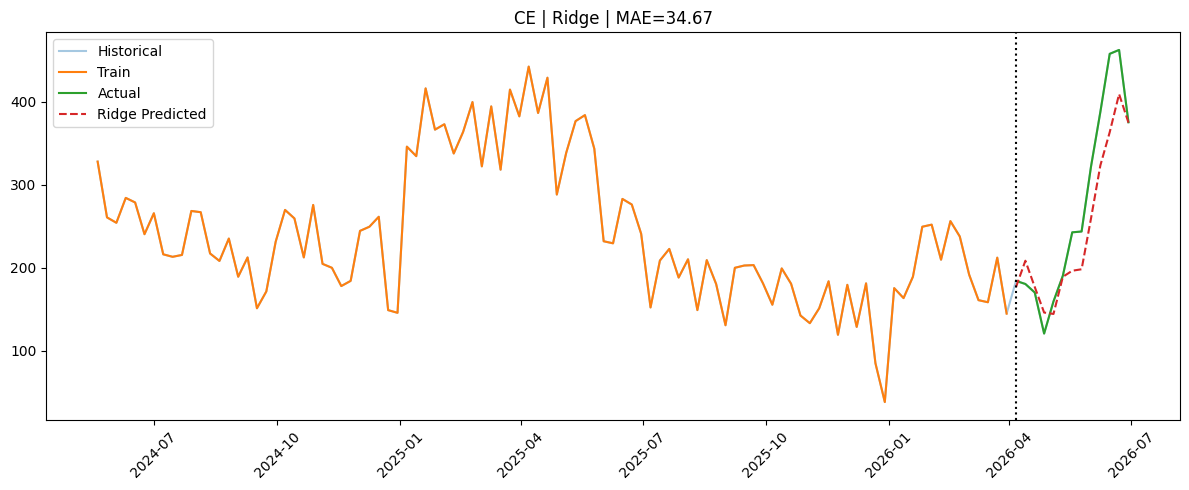

Saved: saved_models\CE__Ridge.pkl


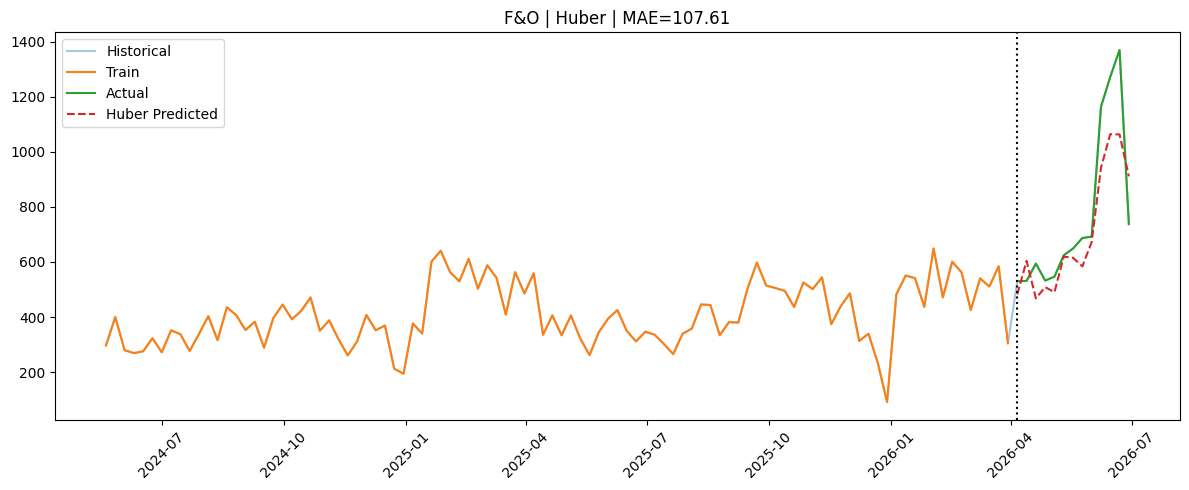

Saved: saved_models\F&O__Huber.pkl


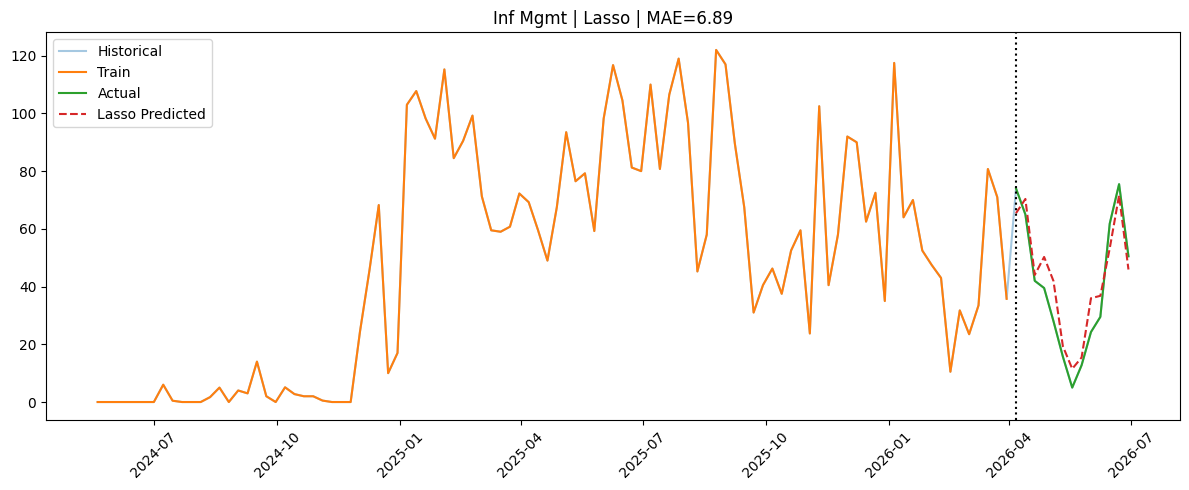

Saved: saved_models\Inf Mgmt__Lasso.pkl


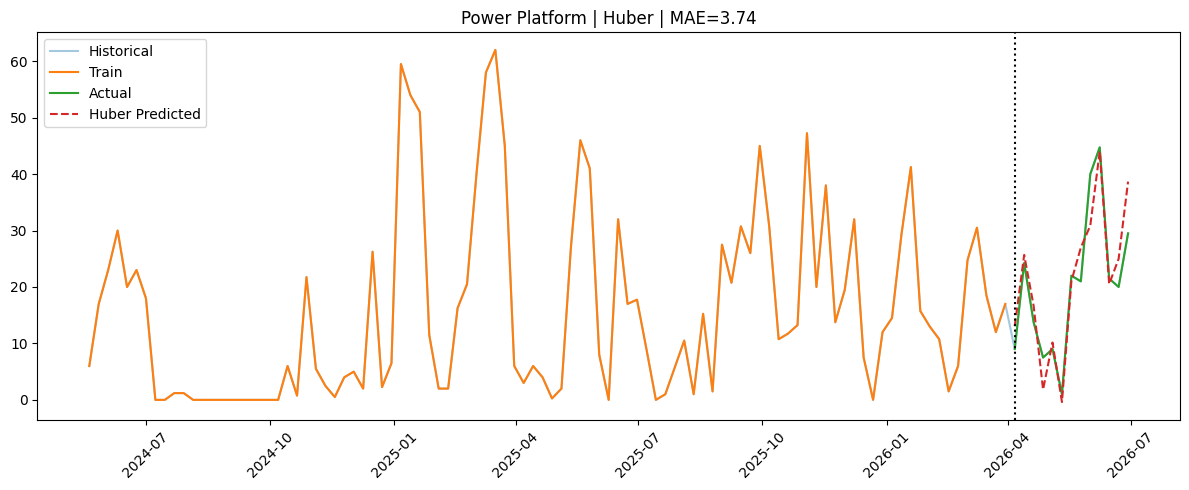

Saved: saved_models\Power Platform__Huber.pkl


In [29]:
results_list = []
feature_importance_results = []

for group_name, df_group in grouped_dfs.items():
    df_group, X, y = build_features(df_group)

    if len(df_group[df_group["Time worked"] > 0]) < 20:
        
        continue

    if df_group["week"].max() < global_end:
        continue

    test_size = 13
    split_idx = len(df_group) - test_size

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]
    
    recent_4 = y_train.tail(4)
    if recent_4.sum() <= 0:
        continue

    (
        model_results,
        best_model,
        best_preds,
        best_name,
        best_mae,
        best_mape
    ) = find_best_model(
        group_name,
        X_train,
        X_test,
        y_train,
        y_test,
        len(df_group)
    )

    results_list.extend(model_results)

    plot_predictions(
        group_name,
        df_group,
        y,
        y_train,
        y_test,
        best_preds,
        best_name,
        best_mae,
        split_idx
    )

    importance_df = generate_xgb_explainability(
        group_name,
        X_train,
        y_train,
        shap_dir
    )

    feature_importance_results.append(
        importance_df
    )

    save_model(
        group_name,
        best_model,
        X,
        y,
        df_group,
        best_name,
        best_mae,
        best_mape,
        model_dir
    )

## Build Inference Pipeline

In [30]:
def forecast_future(
    model,
    features,
    history,
    future_inputs,
    horizon
):

    history = history.copy()

    predictions = []

    for step in range(horizon):

        row = {}

        # business features
        row["is_sick_or_holiday"] = future_inputs.iloc[step]["is_sick_or_holiday"]
        row["is_spike"] = future_inputs.iloc[step]["is_spike"]
        row["is_dip"] = future_inputs.iloc[step]["is_dip"]

        # autoregressive features
        row["lag_1"] = history[-1]
        row["lag_2"] = history[-2]
        row["rolling_4"] = np.mean(history[-4:])

        X_future = pd.DataFrame([row])

        # ensure feature order matches training
        X_future = X_future.reindex(
            columns=features,
            fill_value=0
        )

        pred = model.predict(X_future)[0]

        predictions.append(pred)

        # prediction becomes history
        history.append(pred)

    return predictions

In [39]:
from pathlib import Path
import pickle
import pandas as pd

all_forecasts = []
all_weekly_preds = []           # for global FTE
all_tg_weekly_preds = []        # for per-tech-group FTE

for model_file in Path("saved_models").glob("*.pkl"):
    with open(model_file, "rb") as f:
        pkg = pickle.load(f)

    if "last_week" not in pkg:
        print(f"Skipping {model_file.name}: no last_week found")
        continue

    last_week = pd.to_datetime(pkg["last_week"])

    future_weeks = pd.date_range(
        start=last_week + pd.Timedelta(weeks=1),
        periods=13,
        freq="W"
    )

    future_inputs = pd.DataFrame({"week": future_weeks})

    future_inputs["week_of_year"] = (
        future_inputs["week"]
        .dt.isocalendar()
        .week
        .astype(int)
    )
    future_inputs["month"] = future_inputs["week"].dt.month
    future_inputs["is_month_end"] = future_inputs["week"].dt.is_month_end.astype(int)
    future_inputs["is_quarter_end"] = future_inputs["week"].dt.is_quarter_end.astype(int)

    future_inputs["is_leave"] = 0
    future_inputs["is_sick_or_holiday"] = 0
    future_inputs["is_spike"] = 0
    future_inputs["is_dip"] = 0

    preds = forecast_future(
        model=pkg["model"],
        features=pkg["features"],
        history=pkg["history"],
        future_inputs=future_inputs,
        horizon=13
    )

    row = {"tech_group": pkg["tech_group"]}

    hours_per_fte_per_week = 40 * 0.85

    for week_date, pred in zip(future_weeks, preds):
        week_col = week_date.strftime("%Y-%m-%d")
        row[week_col] = pred

        # Global (all tech_groups)
        all_weekly_preds.append({
            "week": week_col,
            "forecast": pred
        })

        # Per tech_group
        all_tg_weekly_preds.append({
            "tech_group": pkg["tech_group"],
            "week": week_col,
            "forecast": pred
        })

    row["pxn_dt"] = pd.Timestamp.today().date()
    all_forecasts.append(row)


# 1) Demand forecasts CSV (per tech_group, no FTE/hours)
predictions_df = pd.DataFrame(all_forecasts)
predictions_df.to_csv(
    f"predictions_demand_{pd.Timestamp.today().date()}.csv",
    index=False
)

# 2) Global FTE & hours CSV (aggregated across all tech_groups)
global_preds_df = pd.DataFrame(all_weekly_preds)

global_agg = global_preds_df.groupby("week", as_index=False)["forecast"].sum()
global_agg["total_hours_worked"] = global_agg["forecast"]
global_agg["required_fte"] = global_agg["total_hours_worked"] / hours_per_fte_per_week

global_agg.to_csv(
    f"predictions_fte_global_{pd.Timestamp.today().date()}.csv",
    index=False
)

# 3) Per-tech-group FTE & hours CSV
tg_preds_df = pd.DataFrame(all_tg_weekly_preds)

tg_agg = tg_preds_df.groupby(["tech_group", "week"], as_index=False)["forecast"].sum()
tg_agg["total_hours_worked"] = tg_agg["forecast"]
tg_agg["required_fte"] = tg_agg["total_hours_worked"] / hours_per_fte_per_week

tg_agg.to_csv(
    f"predictions_fte_per_tech_group_{pd.Timestamp.today().date()}.csv",
    index=False
)

display(predictions_df)
display(global_agg)
display(tg_agg)

,tech_group,2026-07-12,2026-07-19,2026-07-26,2026-08-02,2026-08-09,2026-08-16,2026-08-23,2026-08-30,2026-09-06,2026-09-13,2026-09-20,2026-09-27,2026-10-04,pxn_dt
0,Azure Integ,125.591867,114.236940,91.804050,98.344105,118.788669,113.303650,110.350727,117.737583,123.907705,123.799064,126.350193,131.450594,135.094843,2026-07-08
1,BC,44.279608,37.068517,28.057456,29.030568,35.355884,33.374413,32.042794,33.073834,34.186399,33.891095,33.947000,34.434924,34.788819,2026-07-08
2,CE,425.677495,480.316486,458.695027,431.634750,467.752055,494.897589,479.901050,476.069354,501.818501,514.977005,508.748076,514.229909,532.151107,2026-07-08
3,F&O,1196.842841,1516.085042,1221.844512,1011.111926,1427.568521,1567.322447,1257.689759,1274.712066,1625.827241,1608.636574,1388.676601,1538.186592,1784.850331,2026-07-08
4,Inf Mgmt,46.825931,64.413243,65.143192,53.666040,55.763372,63.822292,61.873838,57.418131,60.143051,63.422714,61.778455,60.527456,62.544810,2026-07-08
5,Power Platform,26.843888,20.671175,20.184067,21.270446,19.590089,17.508335,16.817662,16.325440,15.243990,14.191955,13.487172,12.817223,12.048378,2026-07-08


,week,forecast,total_hours_worked,required_fte
0,2026-07-12,1866.061630,1866.061630,54.884166
1,2026-07-19,2232.791403,2232.791403,65.670335
2,2026-07-26,1885.728303,1885.728303,55.462597
3,2026-08-02,1645.057836,1645.057836,48.384054
4,2026-08-09,2124.818589,2124.818589,62.494664
5,2026-08-16,2290.228726,2290.228726,67.359668
6,2026-08-23,1958.675829,1958.675829,57.608113
7,2026-08-30,1975.336408,1975.336408,58.098130
8,2026-09-06,2361.126887,2361.126887,69.444908
9,2026-09-13,2358.918407,2358.918407,69.379953


,tech_group,week,forecast,total_hours_worked,required_fte
0,Azure Integ,2026-07-12,125.591867,125.591867,3.693878
1,Azure Integ,2026-07-19,114.236940,114.236940,3.359910
2,Azure Integ,2026-07-26,91.804050,91.804050,2.700119
3,Azure Integ,2026-08-02,98.344105,98.344105,2.892474
4,Azure Integ,2026-08-09,118.788669,118.788669,3.493784
5,Azure Integ,2026-08-16,113.303650,113.303650,3.332460
6,Azure Integ,2026-08-23,110.350727,110.350727,3.245610
7,Azure Integ,2026-08-30,117.737583,117.737583,3.462870
8,Azure Integ,2026-09-06,123.907705,123.907705,3.644344
9,Azure Integ,2026-09-13,123.799064,123.799064,3.641149
